In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("../../data/ltv_prepared_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (7043, 31)

Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'LTV']


LTV column check

In [5]:
print("LTV datatype:", df["LTV"].dtype)

print("\nLTV missing values:", df["LTV"].isna().sum())

print("\nLTV summary:")
print(df["LTV"].describe())

LTV datatype: float64

LTV missing values: 0

LTV summary:
count    7043.000000
mean     2279.581350
std      2264.729447
min         0.000000
25%       394.000000
50%      1393.600000
75%      3786.100000
max      8550.000000
Name: LTV, dtype: float64


Separate X and y

In [6]:
X = df.drop(columns=["LTV"])
y = df["LTV"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget name:", y.name)

Feature shape: (7043, 30)
Target shape: (7043,)

Target name: LTV


Train / Test Split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5634, 30)
Testing features: (1409, 30)
Training target: (5634,)
Testing target: (1409,)


Check data types

In [9]:
# Check missing values
print("Missing values before filling:")
print(X_train.isna().sum()[X_train.isna().sum() > 0])
print("Total missing in X_train:", X_train.isna().sum().sum())

print("\nMissing values in X_test:")
print(X_test.isna().sum()[X_test.isna().sum() > 0])
print("Total missing in X_test:", X_test.isna().sum().sum())

Missing values before filling:
TotalCharges    10
dtype: int64
Total missing in X_train: 10

Missing values in X_test:
TotalCharges    1
dtype: int64
Total missing in X_test: 1


In [10]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("X_train after imputation:", X_train_imputed.shape)
print("X_test after imputation:", X_test_imputed.shape)

X_train after imputation: (5634, 30)
X_test after imputation: (1409, 30)


In [11]:
import numpy as np

print("Missing values after imputation:")
print("X_train:", np.isnan(X_train_imputed).sum())
print("X_test:", np.isnan(X_test_imputed).sum())

Missing values after imputation:
X_train: 0
X_test: 0


Train Linear Regression

In [12]:
from sklearn.linear_model import LinearRegression

# Create model
linear_model = LinearRegression()

# Train model
linear_model.fit(X_train_imputed, y_train)

print("Linear Regression model trained successfully!")
print("Number of features:", X_train_imputed.shape[1])

Linear Regression model trained successfully!
Number of features: 30


Make predictions

In [13]:
y_pred_linear = linear_model.predict(X_test_imputed)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_linear))

print("\nFirst 10 predictions:")
print(y_pred_linear[:10])

Predictions generated successfully!
Number of predictions: 1409

First 10 predictions:
[-1.31047112e+01  1.01598152e+03  1.03916014e+03  7.91938958e+01
  3.27341200e+03  6.13444425e+03  1.73084132e+03  5.00924227e+03
  7.22358767e+03 -5.79365670e+00]


Evaluate Linear Regression

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(mae_linear, 2))
print("RMSE:", round(rmse_linear, 2))
print("R²  :", round(r2_linear, 4))

Linear Regression Results
-------------------------
MAE : 49.73
RMSE: 78.21
R²  : 0.9988


Save Linear Regression model

In [15]:
import joblib
import os

os.makedirs("../data/models", exist_ok=True)

joblib.dump(
    linear_model,
    "../data/models/person3_ltv_linear_regression.pkl"
)

joblib.dump(
    imputer,
    "../data/models/person3_ltv_imputer.pkl"
)

print("Linear Regression model saved successfully!")

Linear Regression model saved successfully!


Random Forest model train

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_imputed, y_train)

print("Random Forest Regressor trained successfully!")
print("Number of trees:", rf_model.n_estimators)

Random Forest Regressor trained successfully!
Number of trees: 200


Predictions

In [17]:
y_pred_rf = rf_model.predict(X_test_imputed)

print("Random Forest predictions generated successfully!")
print("Number of predictions:", len(y_pred_rf))

print("\nFirst 10 predictions:")
print(y_pred_rf[:10])

Random Forest predictions generated successfully!
Number of predictions: 1409

First 10 predictions:
[  24.7535   991.0045  1025.82075   76.48875 3276.07775 6092.453
 1740.4825  5087.0335  7253.46025   19.40575]


Evaluate Random Forest

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Results")
print("--------------------------------")
print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²  :", round(r2_rf, 4))

Random Forest Regression Results
--------------------------------
MAE : 41.48
RMSE: 63.63
R²  : 0.9992


Compare both models

In [19]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor"
    ],
    "MAE": [
        mae_linear,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R2": [
        r2_linear,
        r2_rf
    ]
})

print(comparison.round(4))

                     Model     MAE     RMSE      R2
0        Linear Regression  49.730  78.2106  0.9988
1  Random Forest Regressor  41.476  63.6339  0.9992


Save comparison

In [20]:
os.makedirs("../Reports/week3", exist_ok=True)

comparison.to_csv(
    "../Reports/week3/person3_ltv_model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


Best model

In [21]:
best_model_name = comparison.loc[
    comparison["R2"].idxmax(), "Model"
]

print("Best model based on R²:", best_model_name)

Best model based on R²: Random Forest Regressor


Random Forest Feature Importance

In [22]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 important features:")
print(feature_importance.head(15))

Top 15 important features:
                                  Feature  Importance
3                            TotalCharges    0.998981
1                                  tenure    0.000493
2                          MonthlyCharges    0.000236
15                       OnlineBackup_Yes    0.000019
24                      Contract_One year    0.000019
4                             gender_Male    0.000019
5                             Partner_Yes    0.000018
19                        TechSupport_Yes    0.000018
28         PaymentMethod_Electronic check    0.000018
27  PaymentMethod_Credit card (automatic)    0.000017
26                   PaperlessBilling_Yes    0.000017
0                           SeniorCitizen    0.000017
9                       MultipleLines_Yes    0.000017
6                          Dependents_Yes    0.000017
17                   DeviceProtection_Yes    0.000016


Feature importance chart

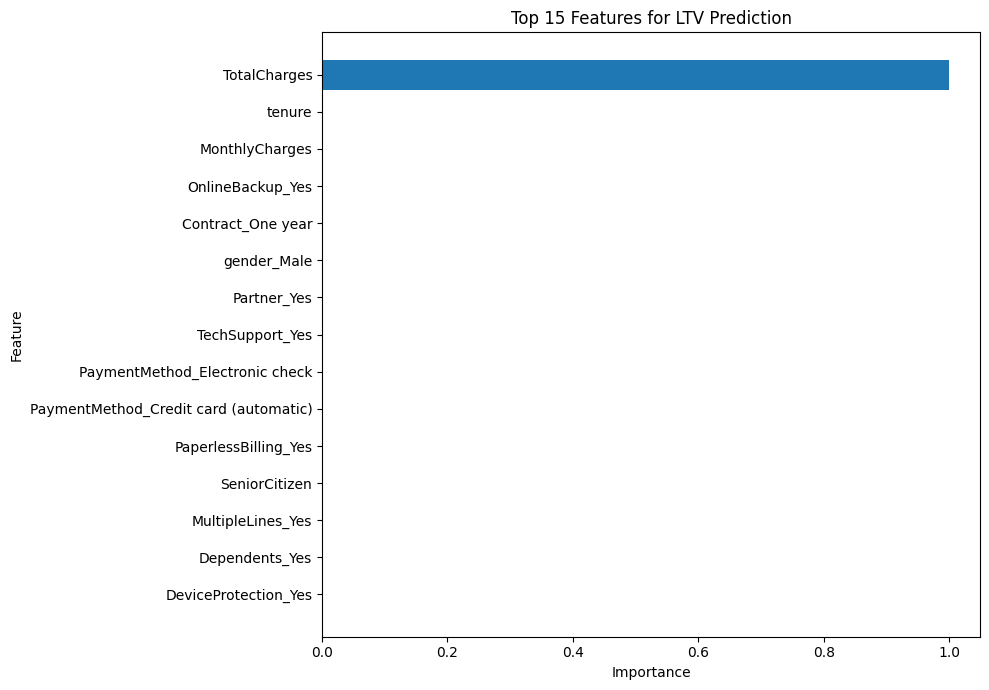

Feature importance chart saved successfully!


In [23]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features for LTV Prediction")
plt.tight_layout()

plt.savefig(
    "../Reports/week3/person3_ltv_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Feature importance chart saved successfully!")

Actual vs Predicted chart

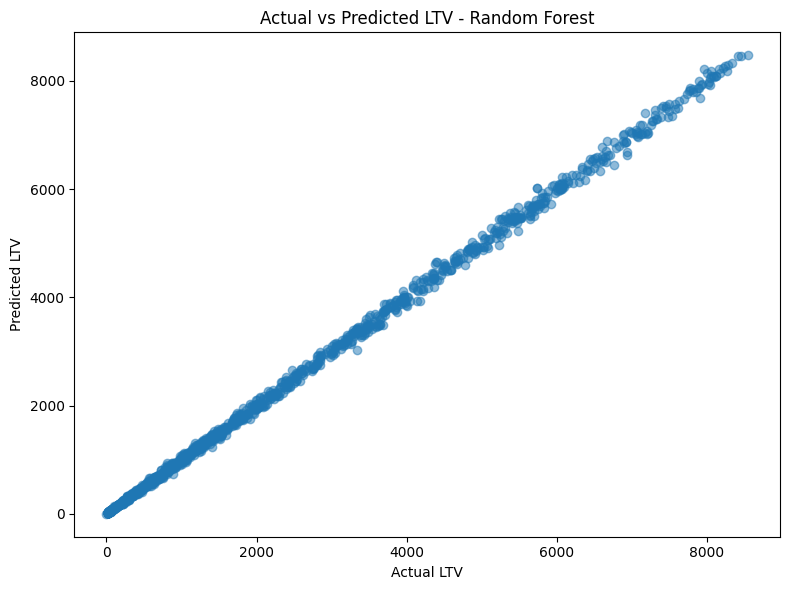

Actual vs Predicted chart saved successfully!


In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.xlabel("Actual LTV")
plt.ylabel("Predicted LTV")
plt.title("Actual vs Predicted LTV - Random Forest")

plt.tight_layout()

plt.savefig(
    "../Reports/week3/person3_actual_vs_predicted_ltv.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Actual vs Predicted chart saved successfully!")

Save best model

In [25]:
import joblib

joblib.dump(
    rf_model,
    "../data/models/person3_best_ltv_random_forest.pkl"
)

print("Best LTV model saved successfully!")

Best LTV model saved successfully!


Complete LTV model report

In [26]:
import os
import pandas as pd

os.makedirs("../Reports/week3", exist_ok=True)

best_row = comparison.loc[comparison["R2"].idxmax()]

report = f"""
# LTV Regression Model Report

## Dataset
Total records: {len(df)}
Features used: {X.shape[1]}

## Models
1. Linear Regression
2. Random Forest Regressor

## Model Performance

### Linear Regression
MAE: {mae_linear:.2f}
RMSE: {rmse_linear:.2f}
R2: {r2_linear:.4f}

### Random Forest Regressor
MAE: {mae_rf:.2f}
RMSE: {rmse_rf:.2f}
R2: {r2_rf:.4f}

## Best Model
Best model based on R2: {best_model_name}

## Conclusion
The model with the highest R2 and comparatively lower error
is selected as the preferred LTV prediction model.
"""

with open("../Reports/week3/person3_ltv_model_report.md", "w", encoding="utf-8") as f:
    f.write(report)

print("LTV model report saved successfully!")

LTV model report saved successfully!
